# Modelo de Previsão do Tempo com Machine Learning

### Nossos dados se referem:

- Série histórica de temperatura do Rio de Janeiro

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score,mean_absolute_percentage_error,mean_squared_error
from xgboost import XGBRegressor

- A coluna "TARGET" se refere a temperatura média de suas respectivas datas

In [121]:
df= pd.read_csv(r"C:\Users\mike\Desktop\DADOS\PROJETOS\ML\MODELO DE PREVISÃO TEMPO\dados_preprocessados_temp_rj.csv")
df.head()

,time,TAMB,seno_mes,cos_mes,media_movel_3m,media_movel_12m,std_movel_3m,std_movel_12m,TARGET
0,1991-12-01,26.519355,-2.449294e-16,1.000000e+00,24.443082,23.412252,1.866790,2.128632,25.835484
1,1992-01-01,25.835484,5.000000e-01,8.660254e-01,25.420502,23.476499,1.354877,2.193676,26.065517
2,1992-02-01,26.065517,8.660254e-01,5.000000e-01,26.140119,23.488506,0.347985,2.208618,26.029032
3,1992-03-01,26.029032,1.000000e+00,6.123234e-17,25.976678,23.530173,0.123631,2.254846,25.043333
4,1992-04-01,25.043333,8.660254e-01,-5.000000e-01,25.712628,23.583506,0.579913,2.284747,23.738710


- Vamos converter a coluna "time" para ser o índice deste Dataset e utilizar "parse_dates=True" para converter nosso Dataset   
 em um **DatetimeIndex**

- **DatetimeIndex** = Mostra para o python que as datas não são apenas strings e sim uma **série temporal**. Nos permitindo   
utilizar funções para manipulação de dados através de datas

In [122]:
df= pd.read_csv(r"C:\Users\mike\Desktop\DADOS\PROJETOS\ML\MODELO DE PREVISÃO TEMPO\dados_preprocessados_temp_rj.csv",
                index_col="time",
                parse_dates=True)
df.head(10)

,TAMB,seno_mes,cos_mes,media_movel_3m,media_movel_12m,std_movel_3m,std_movel_12m,TARGET
time,,,,,,,,
1991-12-01,26.519355,-2.449294e-16,1.000000e+00,24.443082,23.412252,1.866790,2.128632,25.835484
1992-01-01,25.835484,5.000000e-01,8.660254e-01,25.420502,23.476499,1.354877,2.193676,26.065517
1992-02-01,26.065517,8.660254e-01,5.000000e-01,26.140119,23.488506,0.347985,2.208618,26.029032
1992-03-01,26.029032,1.000000e+00,6.123234e-17,25.976678,23.530173,0.123631,2.254846,25.043333
1992-04-01,25.043333,8.660254e-01,-5.000000e-01,25.712628,23.583506,0.579913,2.284747,23.738710
1992-05-01,23.738710,5.000000e-01,-8.660254e-01,24.937025,23.691302,1.148856,2.256497,23.013333
1992-06-01,23.013333,1.224647e-16,-1.000000e+00,23.931792,23.748247,1.028681,2.227456,20.964516
1992-07-01,20.964516,-5.000000e-01,-8.660254e-01,22.572186,23.791257,1.438748,2.161965,20.512903
1992-08-01,20.512903,-8.660254e-01,-5.000000e-01,21.496918,23.773784,1.332526,2.189691,21.476667


In [123]:
df.shape

(406, 8)

,TARGET
count,406.000000
mean,23.791794
std,2.241930
min,19.277419
25%,21.901613
50%,23.811505
75%,25.769605
max,28.864286


(<Axes: xlabel='time'>,)

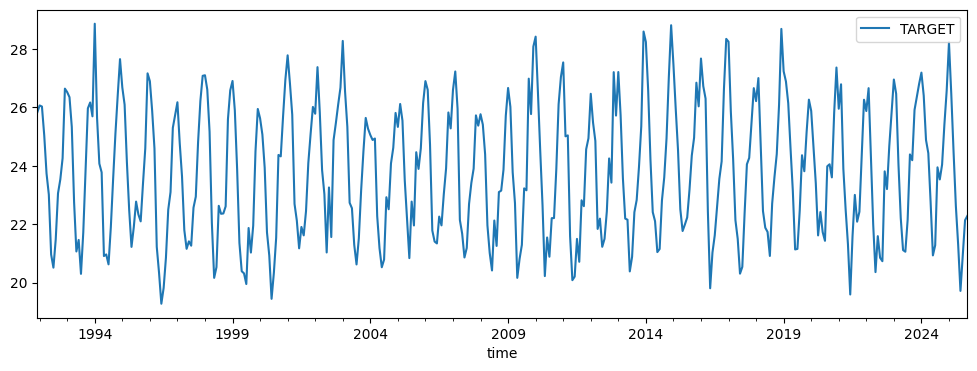

In [124]:
# Estatísticas Basicas dos dados
display(df[["TARGET"]].describe())

# Visualizando os dados com um gráfico de linha
df[["TARGET"]].plot(figsize=(12,4)),

<Axes: xlabel='TARGET', ylabel='Count'>

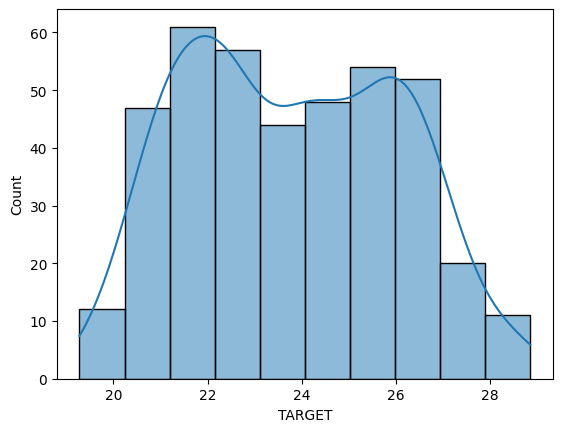

In [125]:
# Visualizando a distribuição dos dados com um histograma
sns.histplot(df["TARGET"], kde=True)

In [126]:
# Criando uma cópia dos dados originais e por que??
# Para evitar modificar os dados originais e sim apenas a cópia. Isso também é importante em alguns casos para nível de comparação entre
#os dados modificados e os dados originais.

df_preprocessado = df.copy()

In [127]:
df_preprocessado.head()

,TAMB,seno_mes,cos_mes,media_movel_3m,media_movel_12m,std_movel_3m,std_movel_12m,TARGET
time,,,,,,,,
1991-12-01,26.519355,-2.449294e-16,1.000000e+00,24.443082,23.412252,1.866790,2.128632,25.835484
1992-01-01,25.835484,5.000000e-01,8.660254e-01,25.420502,23.476499,1.354877,2.193676,26.065517
1992-02-01,26.065517,8.660254e-01,5.000000e-01,26.140119,23.488506,0.347985,2.208618,26.029032
1992-03-01,26.029032,1.000000e+00,6.123234e-17,25.976678,23.530173,0.123631,2.254846,25.043333
1992-04-01,25.043333,8.660254e-01,-5.000000e-01,25.712628,23.583506,0.579913,2.284747,23.738710


In [128]:
# Separando os dados em variáveis de entrada (X) e variável alvo (y)

y = df_preprocessado["TARGET"]
X = df_preprocessado.drop(columns=["TARGET"], axis=1)

In [129]:
display(X.head())
y.head()

,TAMB,seno_mes,cos_mes,media_movel_3m,media_movel_12m,std_movel_3m,std_movel_12m
time,,,,,,,
1991-12-01,26.519355,-2.449294e-16,1.000000e+00,24.443082,23.412252,1.866790,2.128632
1992-01-01,25.835484,5.000000e-01,8.660254e-01,25.420502,23.476499,1.354877,2.193676
1992-02-01,26.065517,8.660254e-01,5.000000e-01,26.140119,23.488506,0.347985,2.208618
1992-03-01,26.029032,1.000000e+00,6.123234e-17,25.976678,23.530173,0.123631,2.254846
1992-04-01,25.043333,8.660254e-01,-5.000000e-01,25.712628,23.583506,0.579913,2.284747


time
1991-12-01    25.835484
1992-01-01    26.065517
1992-02-01    26.029032
1992-03-01    25.043333
1992-04-01    23.738710
Name: TARGET, dtype: float64

- Separação dos dados para treino e teste utilizando o padrão de 70% para treino e 30% para teste

In [130]:
# Primeiros 25 anos destinados para treino

y_train = y["1991":"2015"]
x_train = X["1991":"2015"]


#Últimos 10 anos destinados para teste/validação (2016 - 2025)
y_teste = y["2016":]   # utilizar "2016": significa que eu quero pegar os dados a partir de 2016 até o final do meu dataset
x_teste = X["2016":]

In [131]:
# Aqui estamos tirando a porcentagem exata de dados para os grupos de treino e teste

Percentual_treino = len(y_train) / len(y) * 100
Percentual_teste = len(y_teste) / len(y) * 100

print(f"Percentual de dados para treino: {Percentual_treino:.0f}%")
print(f"Percentual de dados para teste: {Percentual_teste:.0f}%")

Percentual de dados para treino: 71%
Percentual de dados para teste: 29%


- Aplicando o treinamento sobre o modelo

In [132]:
# MODELO UTILIZADO FOI O GRADIENTE BOOSTING: muito utilizado em séries temporais

modelo = XGBRegressor()
modelo.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

- Aplicando as previsões no conjunto de treino e teste dos dados

In [133]:
# modelo.predict(x_teste)

pred_train = pd.DataFrame(modelo.predict(x_train), index=x_train.index, columns=["Y_PRED"])
pred_teste = pd.DataFrame(modelo.predict(x_teste), index=x_teste.index, columns=["Y_PRED"])

pred_teste

,Y_PRED
time,
2016-01-01,27.990925
2016-02-01,26.334280
2016-03-01,25.731443
2016-04-01,22.377686
2016-05-01,22.079344
...,...
2025-05-01,20.863972
2025-06-01,20.886345
2025-07-01,20.941025


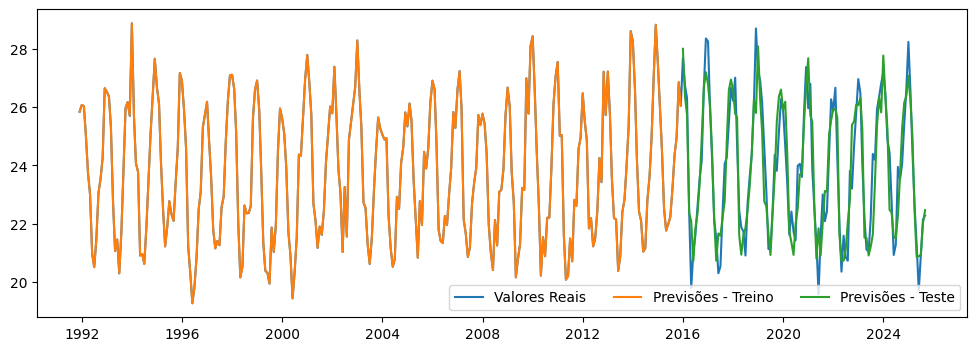

In [134]:
# Plotar previsões vs Dados reais

# Criando figura
fig, ax = plt.subplots(figsize=(12,4))

# Plotando os dados
ax.plot(y, label = "Valores Reais")
ax.plot(pred_train, label = "Previsões - Treino")
ax.plot(pred_teste, label = "Previsões - Teste")

ax.legend(ncol=3)


- Note que nossa plotagem dos dados acima demonstram que nosso modelo interpretou muito bem o conjunto de treino, mas no   
conjunto de teste ele perdeu sua permormance. Isso indica uma alta chance de overfiting em nosso modelo.

- Além da confirmação visual vamos tirar a confirmação numérica abaixo

In [135]:
# R2 >>> COEFICIENTE DE DETERMINAÇÃO
# >> mostra quanto a variável total dos seus dados no modelo consegue explicar
# >> mostra o quão bem seu modelo explica o comportamento da sua série
# >> quanto maior melhor

r2_teste = r2_score(y_true=y_teste, y_pred=pred_teste)
r2_treino = r2_score(y_true=y_train, y_pred=pred_train)

print(f"-- Valores de R2 > Treino: {r2_treino:.2f} | Teste: {r2_teste:.2f} --")


# MAPE >>> ERRO PERCENTUAL ABSOLUTO MÉDIO
# >> medida global do seu modelo
# >> quanto menor melhor

mape_teste = mean_absolute_percentage_error(y_true=y_teste, y_pred=pred_teste) * 100
mape_treino = mean_absolute_percentage_error(y_true=y_train, y_pred=pred_train) * 100

print(f"-- Valores de MAPE > Treino: {mape_treino:.2f}% | Teste: {mape_teste:.2f}% --")

-- Valores de R2 > Treino: 1.00 | Teste: 0.83 --
-- Valores de MAPE > Treino: 0.01% | Teste: 3.05% --


- Vamos parametrizar nosso modelo com configurações mais precisas para nos retornar um resultado sem overfiting

In [136]:
# MODELO UTILIZADO FOI O GRADIENTE BOOSTING: muito utilizado em séries temporais

modelo = XGBRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    colsample_bytree=0.8,
    subsample=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1
)

modelo.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [137]:
# modelo.predict(x_teste)

pred_train = pd.DataFrame(modelo.predict(x_train), index=x_train.index, columns=["Y_PRED"])
pred_teste = pd.DataFrame(modelo.predict(x_teste), index=x_teste.index, columns=["Y_PRED"])

pred_teste

,Y_PRED
time,
2016-01-01,27.116411
2016-02-01,26.095142
2016-03-01,25.659023
2016-04-01,22.764030
2016-05-01,21.742323
...,...
2025-05-01,21.042049
2025-06-01,21.008167
2025-07-01,20.729244


- Note que agora no nosso plot tivemos uma margem de erro aparente no conjunto de treino. Demonstrando que nosso modelo   
com parâmetros específicos não ficou viciado nos dados ao treina-lo, nos resultando em um bom desempenho sem overfiting

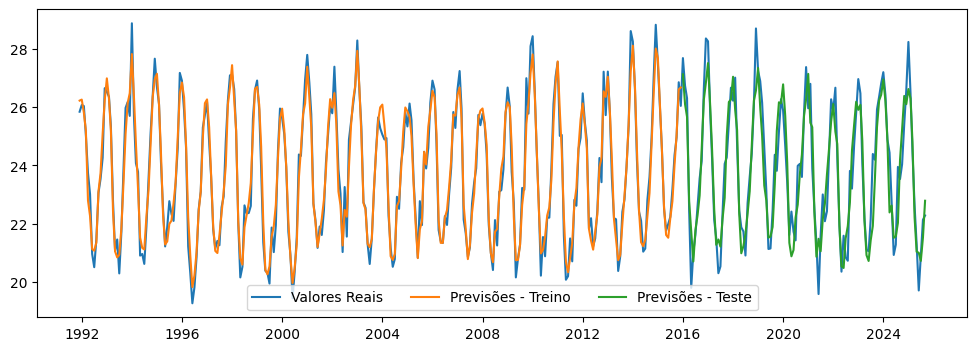

In [138]:
# Plotar previsões vs Dados reais

# Criando figura
fig, ax = plt.subplots(figsize=(12,4))

# Plotando os dados
ax.plot(y, label = "Valores Reais")
ax.plot(pred_train, label = "Previsões - Treino")
ax.plot(pred_teste, label = "Previsões - Teste")

ax.legend(ncol=3)


- Note que agora tivemos uma porcentagem de acerto menor no conjunto de treino e maior no conjunto de teste.   
  - A margem de erro para o conjunto de treino subiu e para teste reduziu 

### **Mas afinal, por que ter um acerto de 100% no teste é ruim???**

- Basicamente é o seguinte. Quando um modelo atinge 100% de acerto no treino, significa que ele não aprendeu e sim decorou os dados,  
ou seja, praticamente copiou os dados ao invés de aprender com eles. Ao utilizar o que foi aprendido no treino para executar no teste  
ele sofre uma baixa significativa no desempenho de suas previsões.  
Por isso, não atingir 100% de acertividade no treinamento é positivo, pois demonstra que o modelo não sofreu de **overfiting que é o processo descrito acima, onde o modelo ao invés de aprender com os dados ele decora**

- **Agora podemos notar abaixo que tivemos uma melhora no desempenho do nosso modelo depois de parametrizar ajustando configurações**

In [139]:
# R2 >>> COEFICIENTE DE DETERMINAÇÃO
# >> mostra quanto a variável total dos seus dados no modelo consegue explicar
# >> mostra o quão bem seu modelo explica o comportamento da sua série
# >> quanto maior melhor

r2_teste = r2_score(y_true=y_teste, y_pred=pred_teste)
r2_treino = r2_score(y_true=y_train, y_pred=pred_train)

print(f"-- Valores de R2 > Treino: {r2_treino:.2f} | Teste: {r2_teste:.2f} --")


# MAPE >>> ERR PERCENTUAL ABSOLUTO MÉDIO
# >> medida global do seu modelo
# >> quanto menor melhor

mape_teste = mean_absolute_percentage_error(y_true=y_teste, y_pred=pred_teste) * 100
mape_treino = mean_absolute_percentage_error(y_true=y_train, y_pred=pred_train) * 100

print(f"-- Valores de MAPE > Treino: {mape_treino:.2f}% | Teste: {mape_teste:.2f}% --")

-- Valores de R2 > Treino: 0.96 | Teste: 0.85 --
-- Valores de MAPE > Treino: 1.49% | Teste: 2.94% --
